In [1]:
import os
import glob
import pickle
import itertools

import matplotlib.pyplot as plt
import numpy as np

In [2]:
model_files = glob.glob("/u/home/s/skirti/dipoppa-lab/dipoppa-lab/thalamocortical-expansion/02_code/thalamocortical_powerlaw/results_ringach_grid/*.pkl")
models = []

for file in model_files:
    with open(file, 'rb') as f:
        models.append(pickle.load(f))

In [3]:
lgn_shapes = [32, 64, 128, 256, 512, 1024]

## the untrained model
Just uses the base initialized model with probabilistic connections between LGN and V1

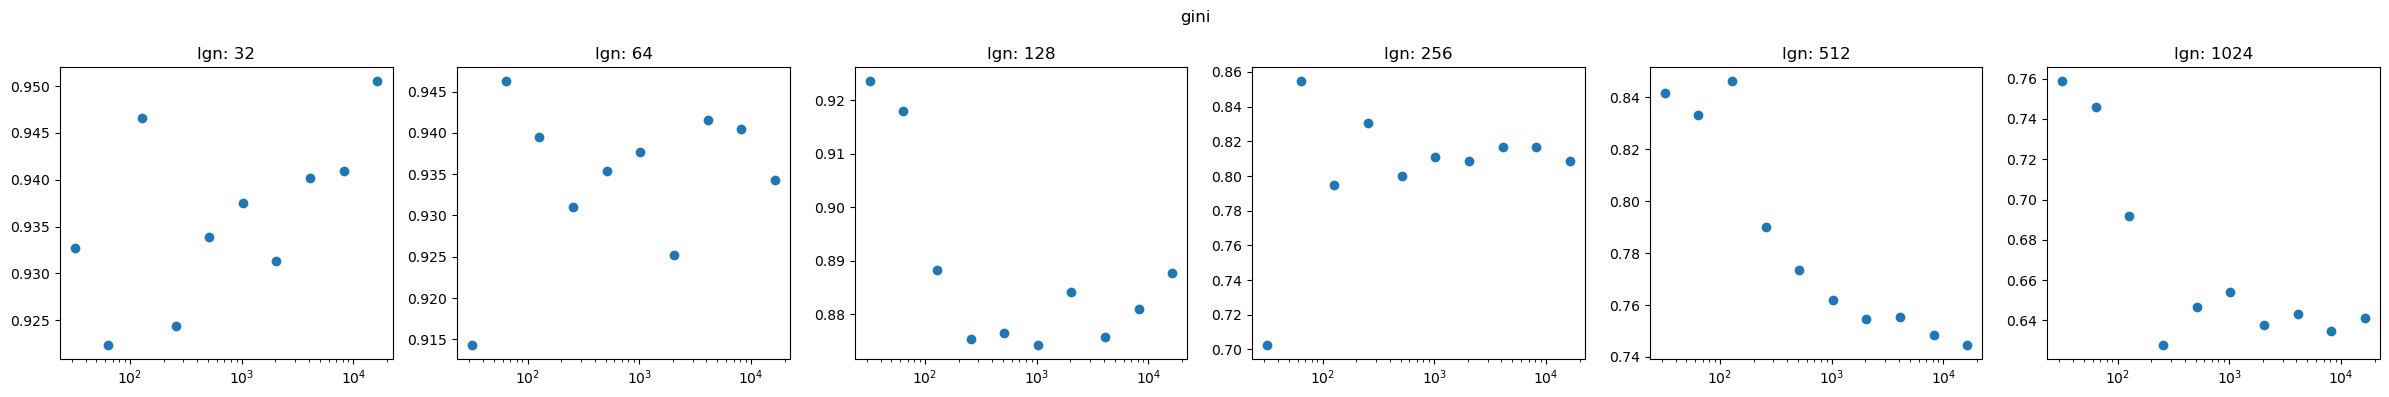

In [7]:
fig, ax = plt.subplots(1, 6, figsize=(24, 4)) #, sharex=True, sharey=True)

for i_row in range(6):
    model_spec = [m for m in models if m["lgn_params"] == lgn_shapes[i_row]]
    ax[i_row].scatter([ms["v1_params"] for ms in model_spec], [np.abs(ms["v1_gini"]) for ms in model_spec])
    ax[i_row].set_title(f"lgn: {lgn_shapes[i_row]}")
    ax[i_row].set_xscale("log")
    
plt.suptitle("gini")
fig.set_tight_layout(True)
plt.show()

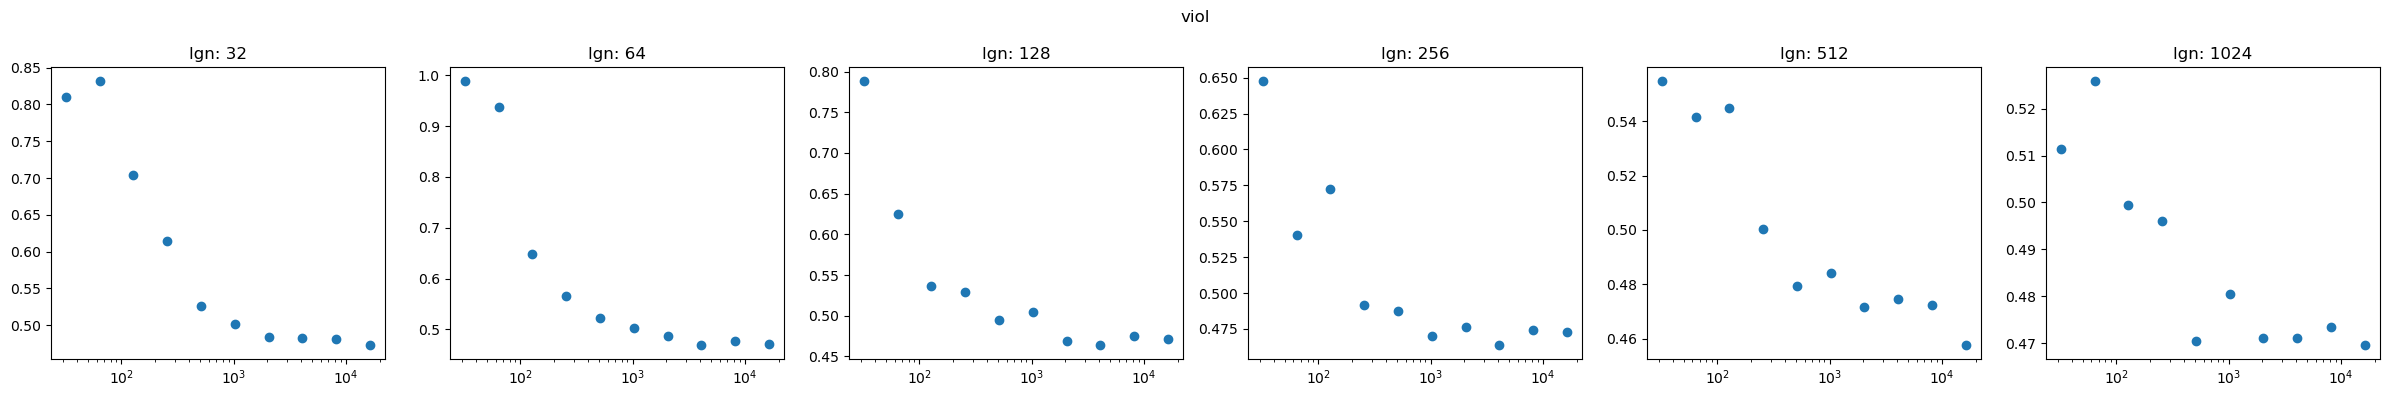

In [9]:
fig, ax = plt.subplots(1, 6, figsize=(24, 4)) #, sharex=True, sharey=True)

for i_row in range(6):
    model_spec = [m for m in models if m["lgn_params"] == lgn_shapes[i_row]]
    ax[i_row].scatter([ms["v1_params"] for ms in model_spec], [ms["test_viol"] for ms in model_spec])
    ax[i_row].set_title(f"lgn: {lgn_shapes[i_row]}")
    ax[i_row].set_xscale("log")
    
plt.suptitle("viol")
fig.set_tight_layout(True)
plt.show()

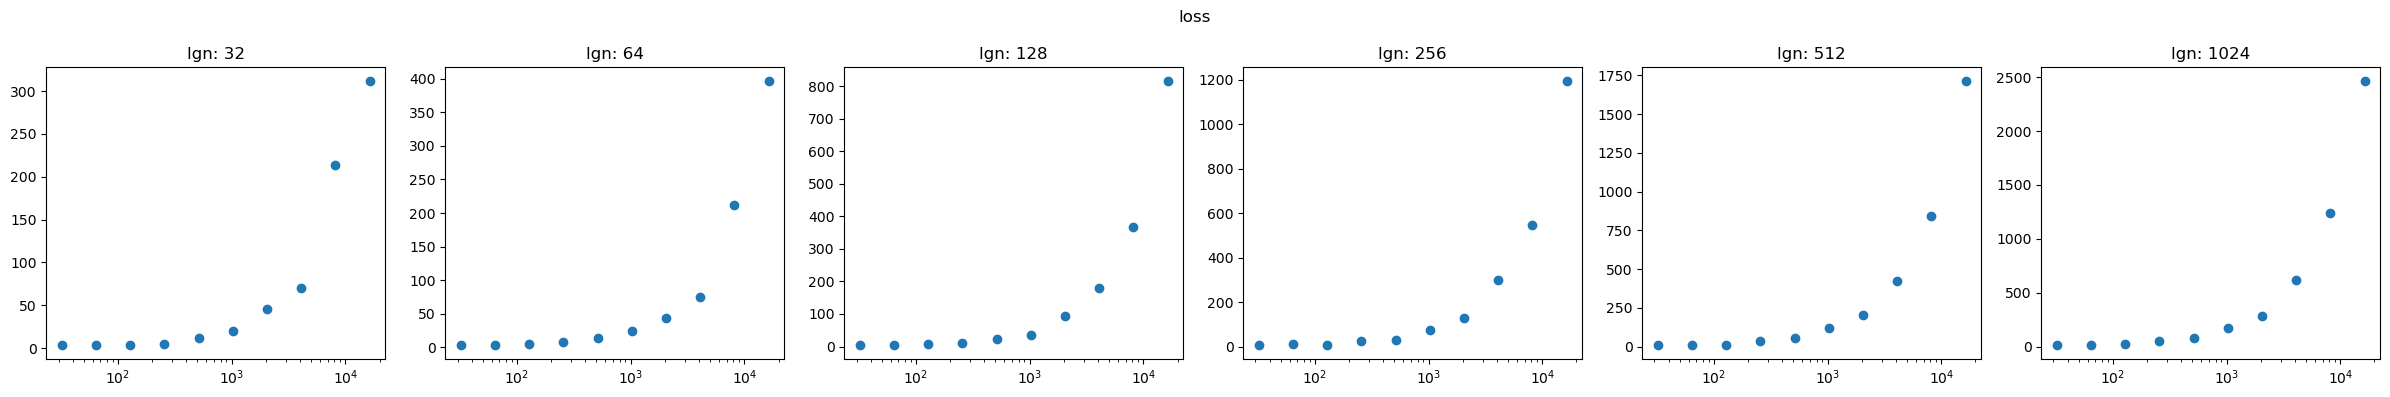

In [10]:
fig, ax = plt.subplots(1, 6, figsize=(24, 4)) #, sharex=True, sharey=True)

for i_row in range(6):
    model_spec = [m for m in models if m["lgn_params"] == lgn_shapes[i_row]]
    ax[i_row].scatter([ms["v1_params"] for ms in model_spec], [ms["test_loss"] for ms in model_spec])
    ax[i_row].set_title(f"lgn: {lgn_shapes[i_row]}")
    ax[i_row].set_xscale("log")
    
plt.suptitle("loss")
fig.set_tight_layout(True)
plt.show()

## unconstrained trained model
allowing the LGN-V1 weights to be entirely optimized over

## constrained trained model
here we add a penalty for models which have weights to farther LGN cells, a sort of optimization that favors closer connections